In [8]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd


In [9]:
import geopandas as gpd
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rasterio.transform import from_origin

# Load the GeoPackage (Coastal Vulnerability Data)
gpkg_path = "../../data/EMODNET/coastal_type (2)/EMODnetCoastalType.gpkg"
gdf = gpd.read_file(gpkg_path)

# Rename 'CoastType' to 'CVI' if required
# If you plan to refer to it as 'CVI' throughout, rename it
#gdf.rename(columns={'CoastType': 'CVI'}, inplace=True)

# Convert 'CVI' to categorical if it's not already
#gdf['CVI'] = gdf['CVI'].astype('category')

# Convert CRS to EPSG:4326 (lat/lon)
gdf = gdf.to_crs(epsg=4326)

# Check geometry type and assign latitude and longitude based on the geometry type
if gdf.geometry.geom_type.iloc[0] == 'Point':
    gdf['latitude'] = gdf.geometry.y
    gdf['longitude'] = gdf.geometry.x
else:
    # If it's not a point, calculate the centroid for non-Point geometries
    gdf['latitude'] = gdf.geometry.centroid.y
    gdf['longitude'] = gdf.geometry.centroid.x

# Load raster data (Wave and Current)
def load_raster_data(raster_path):
    with rasterio.open(raster_path) as raster:
        raster_data = raster.read(1)  # Read the first band
        transform = raster.transform  # Affine transform
        crs = raster.crs  # Coordinate reference system
        bounds = raster.bounds  # Get the bounds (min, max)
    return raster_data, transform, crs, bounds

# Paths to wave and current rasters
wave_raster_path_NC = "/Users/lb962/Documents/Phd/CoastalCluster/data/ke_waves_NC_withconf/ke_waves_NC_conf.tif"
wave_raster_path_atlantic = "/Users/lb962/Documents/Phd/CoastalCluster/data/ke_waves_NC_withconf/ke_waves_atlantic.tif"
current_raster_path = "/Users/lb962/Documents/Phd/CoastalCluster/data/ke_currents_atlantic_withconf/ke_currents_atlantic.tif"

# Load all raster data
wave_nc_data, wave_nc_transform, wave_nc_crs, wave_nc_bounds = load_raster_data(wave_raster_path_NC)
wave_atlantic_data, wave_atlantic_transform, wave_atlantic_crs, wave_atlantic_bounds = load_raster_data(wave_raster_path_atlantic)
current_data, current_transform, current_crs, current_bounds = load_raster_data(current_raster_path)

# Generate a grid of latitudes and longitudes for the raster data
def generate_lat_lon_grid(raster_data, raster_transform):
    rows, cols = raster_data.shape
    lon, lat = np.meshgrid(
        np.linspace(raster_transform[2], raster_transform[2] + raster_transform[0] * cols, cols),
        np.linspace(raster_transform[5] + raster_transform[4] * rows, raster_transform[5], rows)
    )
    return lat, lon

# Generate lat/lon grids for each raster
wave_nc_lat, wave_nc_lon = generate_lat_lon_grid(wave_nc_data, wave_nc_transform)
wave_atlantic_lat, wave_atlantic_lon = generate_lat_lon_grid(wave_atlantic_data, wave_atlantic_transform)
current_lat, current_lon = generate_lat_lon_grid(current_data, current_transform)

# Create DataFrame for wave and current data with latitude/longitude
def create_raster_df(lat, lon, data, variable_name):
    df = pd.DataFrame({
        'latitude': lat.flatten(),
        'longitude': lon.flatten(),
        variable_name: data.flatten()
    })
    return df

# Create DataFrames for wave and current data
wave_nc_df = create_raster_df(wave_nc_lat, wave_nc_lon, wave_nc_data, 'Wave_NC')
wave_atlantic_df = create_raster_df(wave_atlantic_lat, wave_atlantic_lon, wave_atlantic_data, 'Wave_Atlantic')
current_df = create_raster_df(current_lat, current_lon, current_data, 'Current')

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in 'EMODnetCoastalType.gpkg': 'Original' (default), '02', '2', '005', '05', '015', '0025', '01', '1', 'layer_styles'. Specify layer parameter to avoid this warning.
  result = read_func(
/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_2735/1963942796.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['latitude'] = gdf.geometry.centroid.y
/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_2735/1963942796.py:29: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['longitude'] = gdf.geometry.centroid.x


In [10]:
# Path to the GeoPackage file
gpkg_path = "/Users/lb962/Documents/Phd/CoastalCluster/data/coastal_vulnerability_resilience/20241218_GeneraliserenCoastalVulnerabilitySHP.gpkg"

# Load the specific layer from the GeoPackage
CVI_gdf = gpd.read_file(gpkg_path, layer='CVI_0.15')

# Check the unique values in the 'CVI' column to understand how it is represented
print(CVI_gdf['CVI'].unique())

# Convert 'CVI' to a categorical type if it's not already
CVI_gdf['CVI'] = CVI_gdf['CVI'].astype('category')

# Reproject to EPSG:4326 (WGS84 lat/lon)
CVI_gdf = CVI_gdf.to_crs(epsg=4326)

# Add latitude and longitude from the geometry (centroid if not a point)
CVI_gdf['latitude'] = CVI_gdf.geometry.centroid.y
CVI_gdf['longitude'] = CVI_gdf.geometry.centroid.x

# Convert GeoDataFrame to a regular DataFrame (without geometry)
CVI_df = CVI_gdf.drop(columns='geometry')

DataSourceError: /Users/lb962/Documents/Phd/CoastalCluster/data/coastal_vulnerability_resilience/20241218_GeneraliserenCoastalVulnerabilitySHP.gpkg: No such file or directory

In [11]:
# Function to round latitude and longitude to the nearest 0.25
def round_lat_lon_to_0_25(df):
    df['latitude'] = (df['latitude'] / 0.25).round() * 0.25  # Round to nearest 0.25
    df['longitude'] = (df['longitude'] / 0.25).round() * 0.25  # Round to nearest 0.25
    return df

# Apply exact rounding to the respective DataFrames
gdf = round_lat_lon_to_0_25(gdf)
#CVI_df = round_lat_lon_to_0_25(CVI_df)
wave_nc_df = round_lat_lon_to_0_25(wave_nc_df)
wave_atlantic_df = round_lat_lon_to_0_25(wave_atlantic_df)
current_df = round_lat_lon_to_0_25(current_df)

In [12]:
# Define the latitude and longitude bounds for UK and Ireland
lat_min = 49.5
lat_max = 60.9
lon_min = -10.5
lon_max = 1.8

# Filter the DataFrames to only include rows within the UK and Ireland bounds
gdf_filtered = gdf[(gdf['latitude'] >= lat_min) & (gdf['latitude'] <= lat_max) &
                   (gdf['longitude'] >= lon_min) & (gdf['longitude'] <= lon_max)]

#CVI_df_filtered = CVI_df[(CVI_df['latitude'] >= lat_min) & (CVI_df['latitude'] <= lat_max) &
       #                  (CVI_df['longitude'] >= lon_min) & (CVI_df['longitude'] <= lon_max)]

wave_nc_df_filtered = wave_nc_df[(wave_nc_df['latitude'] >= lat_min) & (wave_nc_df['latitude'] <= lat_max) &
                                  (wave_nc_df['longitude'] >= lon_min) & (wave_nc_df['longitude'] <= lon_max)]

wave_atlantic_df_filtered = wave_atlantic_df[(wave_atlantic_df['latitude'] >= lat_min) & (wave_atlantic_df['latitude'] <= lat_max) &
                                             (wave_atlantic_df['longitude'] >= lon_min) & (wave_atlantic_df['longitude'] <= lon_max)]

current_df_filtered = current_df[(current_df['latitude'] >= lat_min) & (current_df['latitude'] <= lat_max) &
                                  (current_df['longitude'] >= lon_min) & (current_df['longitude'] <= lon_max)]

In [13]:
# Drop duplicates based on latitude and longitude in the filtered DataFrames
gdf_filtered = gdf_filtered.drop_duplicates(subset=['latitude', 'longitude'])
#CVI_df_filtered = CVI_df_filtered.drop_duplicates(subset=['latitude', 'longitude'])
wave_nc_df_filtered = wave_nc_df_filtered.drop_duplicates(subset=['latitude', 'longitude'])
wave_atlantic_df_filtered = wave_atlantic_df_filtered.drop_duplicates(subset=['latitude', 'longitude'])
current_df_filtered = current_df_filtered.drop_duplicates(subset=['latitude', 'longitude'])

In [14]:
# Now, merge all the filtered DataFrames
df_combined = gdf_filtered[['latitude', 'longitude', 'CoastType']].copy()  # Adjust column name as needed

# Merge the filtered DataFrames one by one
#df_combined = df_combined.merge(CVI_df_filtered, on=['latitude', 'longitude'], how='left')
df_combined = df_combined.merge(wave_nc_df_filtered, on=['latitude', 'longitude'], how='left')
df_combined = df_combined.merge(wave_atlantic_df_filtered, on=['latitude', 'longitude'], how='left')
df_combined = df_combined.merge(current_df_filtered, on=['latitude', 'longitude'], how='left')

# Print the first few rows of the combined DataFrame
print(df_combined.head())

# Optionally, save the combined DataFrame to a CSV file for further analysis
df_combined.to_csv("filtered_combined_data.csv", index=False)

   latitude  longitude                                          CoastType  \
0     50.00       1.00                                        Harbor area   
1     50.00       0.75                                      Small beaches   
2     49.75       0.75  Erodible rock and/or cliff, with rock waste an...   
3     49.75       0.50  Erodible rock and/or cliff, with rock waste an...   
4     49.75       0.25                                        Harbor area   

   Wave_NC  Wave_Atlantic  Current  
0        1           0.30   5.2631  
1        1           0.43   6.6141  
2        1           0.29   5.7105  
3        1           0.27   5.8718  
4        1           0.92   9.2117  


In [ ]:
hallo

In [ ]:

# Merge all data into one DataFrame based on latitude and longitude
# Assuming 'gdf' has already been transformed to EPSG:4326 (lat/lon)
#df_combined = gdf[['latitude', 'longitude', 'CVI']].copy()

# Merge raster data with the vector data
df_combined = df_combined.merge(wave_nc_df, on=['latitude', 'longitude'], how='left')
df_combined = df_combined.merge(wave_atlantic_df, on=['latitude', 'longitude'], how='left')
df_combined = df_combined.merge(current_df, on=['latitude', 'longitude'], how='left')

# Check the combined DataFrame
print(df_combined.head())

: 

: 

KeyError: 'CVI'

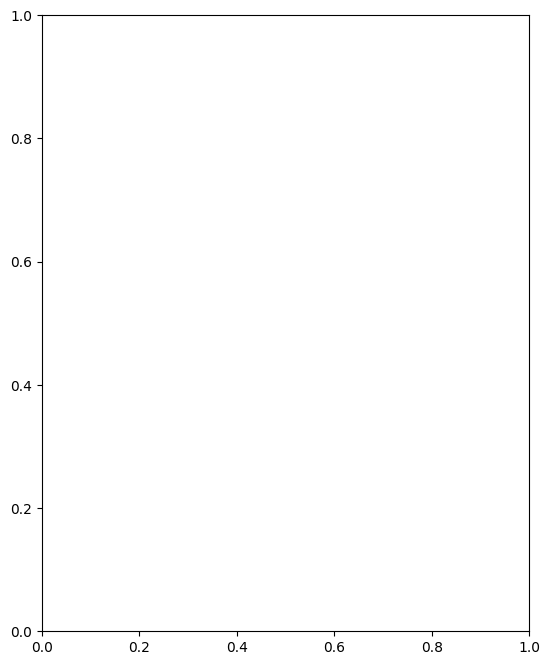

In [15]:

# Optionally, you can save it to a CSV for further processing or clustering
df_combined.to_csv("combined_coastal_data.csv", index=False)

# Plot combined data (optional)
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the data based on the "CVI" column (Coastal Vulnerability Index)
gdf.plot(ax=ax, column='CVI', cmap='Set3', legend=True, categorical=True, edgecolor='black', alpha=0.7)
ax.set_title("Combined Coastal Data: Vulnerability, Wave, and Current")
plt.tight_layout()
plt.show()

In [16]:
# Check the available columns in the GeoDataFrame
print("Available columns in gdf:", gdf.columns)

# Optionally, inspect the first few rows to see the actual structure of the data
print("First few rows of the gdf:", gdf.head())


Available columns in gdf: Index(['Morpho', 'CoastType', 'geometry', 'latitude', 'longitude'], dtype='object')
First few rows of the gdf:   Morpho            CoastType  \
0      X  Heterogeneous beach   
1      X  Heterogeneous beach   
2      X  Heterogeneous beach   
3      X  Heterogeneous beach   
4      X  Heterogeneous beach   

                                            geometry  latitude  longitude  
0  MULTILINESTRING ((30.67964 46.32257, 30.67989 ...     46.25      30.75  
1  MULTILINESTRING ((31.55606 46.61064, 31.55605 ...     46.50      31.50  
2  MULTILINESTRING ((30.76759 46.45381, 30.76745 ...     46.50      30.75  
3  MULTILINESTRING ((31.36377 46.62125, 31.3617 4...     46.50      31.25  
4  MULTILINESTRING ((31.26913 46.61157, 31.26849 ...     46.50      31.25  


In [17]:
# Load the GeoPackage file
gpkg_path = "../data/coastal_type (2)/EMODnetCoastalType.gpkg"
gdf = gpd.read_file(gpkg_path)

# Rename GeoDataFrame as coastaltype_gdf
coastaltype_gdf = gdf

if coastaltype_gdf.crs and coastaltype_gdf .crs != "EPSG:4326":
    coastaltype_gdf = coastaltype_gdf .to_crs("EPSG:4326")

# Choose a column for coloring (update this with a relevant column)
color_column = coastaltype_gdf.columns[1]

# Define the map boundaries: Iceland (-25°W) to France (10°E), 35°N to 65°N
extent = [-15, 10, 45, 65]  

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Add base features
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Set the focused extent (Iceland to France)
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Plot the coastal data with different colors
coastaltype_gdf.plot(ax=ax, transform=ccrs.PlateCarree(), column=color_column, cmap="tab10", legend=True, alpha=0.7)

# Place the legend outside the plot
plt.title("Coastal Type Data: Iceland to France")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title=color_column)

# Adjust layout to ensure everything fits
plt.tight_layout()

plt.show()

DataSourceError: ../data/coastal_type (2)/EMODnetCoastalType.gpkg: No such file or directory

In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Path to the GeoPackage file
gpkg_path = "/Users/lb962/Documents/Phd/CoastalCluster/data/coastal_vulnerability_resilience/20241218_GeneraliserenCoastalVulnerabilitySHP.gpkg"

# Load the specific layer from the GeoPackage (adjust if needed)
gdf = gpd.read_file(gpkg_path, layer='CVI_0.15')  # Ensure that the layer name is correct

# Print the first few rows to inspect the 'CVI' column
print(gdf.head())

# Check the unique values in the 'CVI' column to understand how it is represented
print(gdf['CVI'].unique())

# If CVI is categorical (e.g., 'Low', 'Intermediate', 'High'), we can map them to categories
# Convert 'CVI' to a categorical type if not already
gdf['CVI'] = gdf['CVI'].astype('category')

# Ensure that the GeoDataFrame is in the correct CRS for Cartopy (EPSG:4326, which is lat/lon)
gdf = gdf.to_crs(epsg=4326)

# Create a map using Cartopy with PlateCarree projection (latitude/longitude)
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Add base features like coastlines and borders
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Plot the GeoDataFrame over the map using the 'CVI' variable for coloring
gdf.plot(ax=ax, transform=ccrs.PlateCarree(), column='CVI', cmap='Set3', legend=True, 
         categorical=True, edgecolor='black', alpha=0.7) #legend_kwds={'orientation': 'horizontal'})

# Set the title and labels
ax.set_title("Coastal Vulnerability and Resilience Map")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Show the plot
plt.tight_layout()
plt.show()


DataSourceError: /Users/lb962/Documents/Phd/CoastalCluster/data/coastal_vulnerability_resilience/20241218_GeneraliserenCoastalVulnerabilitySHP.gpkg: No such file or directory

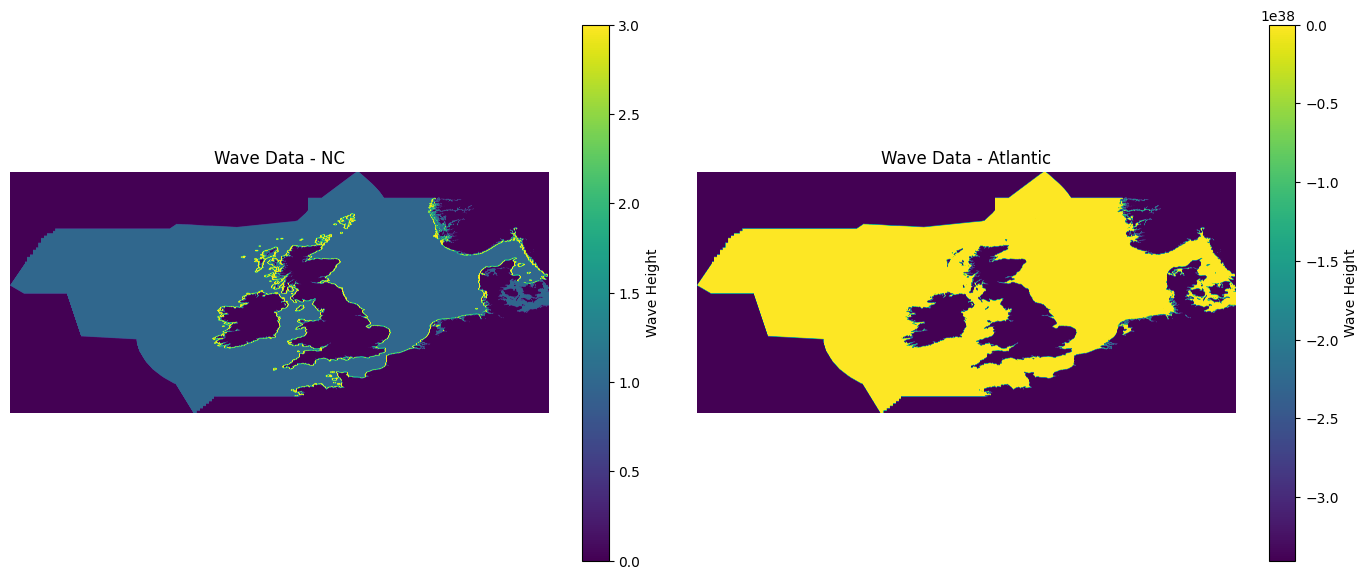

In [19]:
import rasterio

# Paths to the wave raster files
wave_raster_path_NC = "/Users/lb962/Documents/Phd/CoastalCluster/data/ke_waves_NC_withconf/ke_waves_NC_conf.tif"
wave_raster_path_atlantic = "/Users/lb962/Documents/Phd/CoastalCluster/data/ke_waves_NC_withconf/ke_waves_atlantic.tif"

# Open the wave raster files using rasterio
with rasterio.open(wave_raster_path_NC) as wave_nc:
    wave_nc_data = wave_nc.read(1)  # Read the first band of the raster

with rasterio.open(wave_raster_path_atlantic) as wave_atlantic:
    wave_atlantic_data = wave_atlantic.read(1)  # Read the first band of the raster
# Plotting the wave data
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Plot NC wave data
cax_nc = ax[0].imshow(wave_nc_data, cmap='viridis')
ax[0].set_title("Wave Data - NC")
ax[0].axis('off')  # Turn off axis

# Plot Atlantic wave data
cax_atlantic = ax[1].imshow(wave_atlantic_data, cmap='viridis')
ax[1].set_title("Wave Data - Atlantic")
ax[1].axis('off')  # Turn off axis

# Add colorbars (legends) for both plots
fig.colorbar(cax_nc, ax=ax[0], orientation='vertical', shrink=0.8, label="Wave Height")
fig.colorbar(cax_atlantic, ax=ax[1], orientation='vertical', shrink=0.8, label="Wave Height")

# Show the plots
plt.tight_layout()
plt.show()

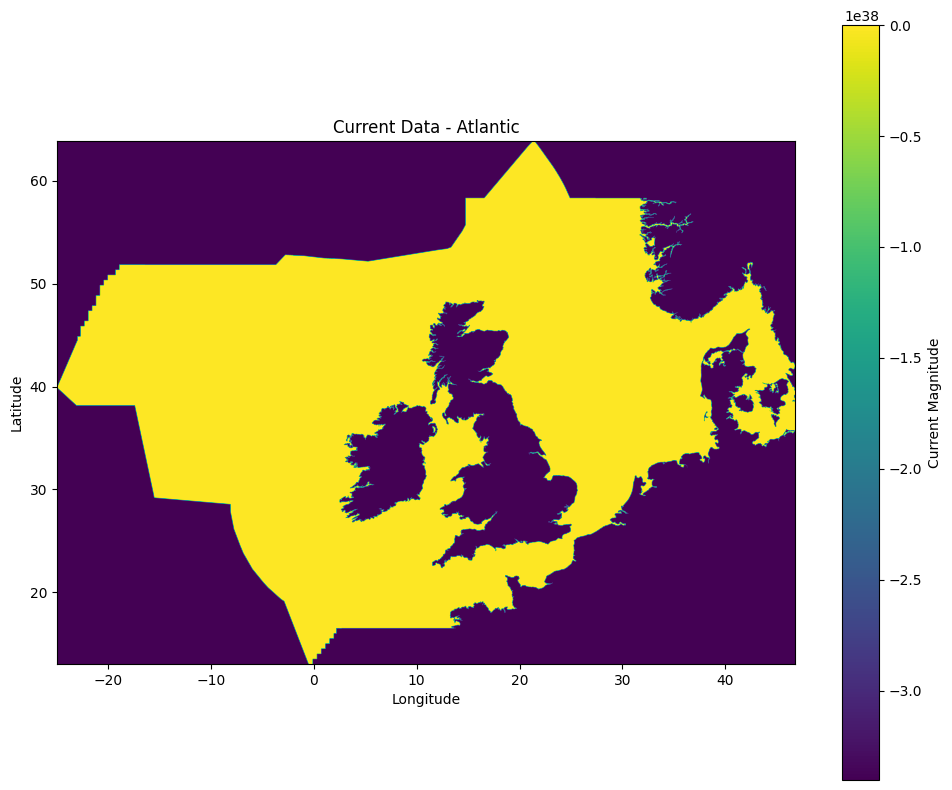

In [20]:
import rasterio
import matplotlib.pyplot as plt

# Path to the current raster file
current_raster_path = "/Users/lb962/Documents/Phd/CoastalCluster/data/ke_currents_atlantic_withconf/ke_currents_atlantic.tif"

# Open the current raster file using rasterio
with rasterio.open(current_raster_path) as current_raster:
    current_data = current_raster.read(1)  # Read the first band
    current_transform = current_raster.transform  # Get the affine transform
    current_crs = current_raster.crs  # Coordinate reference system
    current_bounds = current_raster.bounds  # Get the bounds (min, max)

# Plotting the raster data
plt.figure(figsize=(10, 8))
plt.imshow(current_data, cmap='viridis', origin='upper', extent=current_bounds)
plt.colorbar(label="Current Magnitude")  # Add a colorbar for magnitude representation
plt.title("Current Data - Atlantic")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


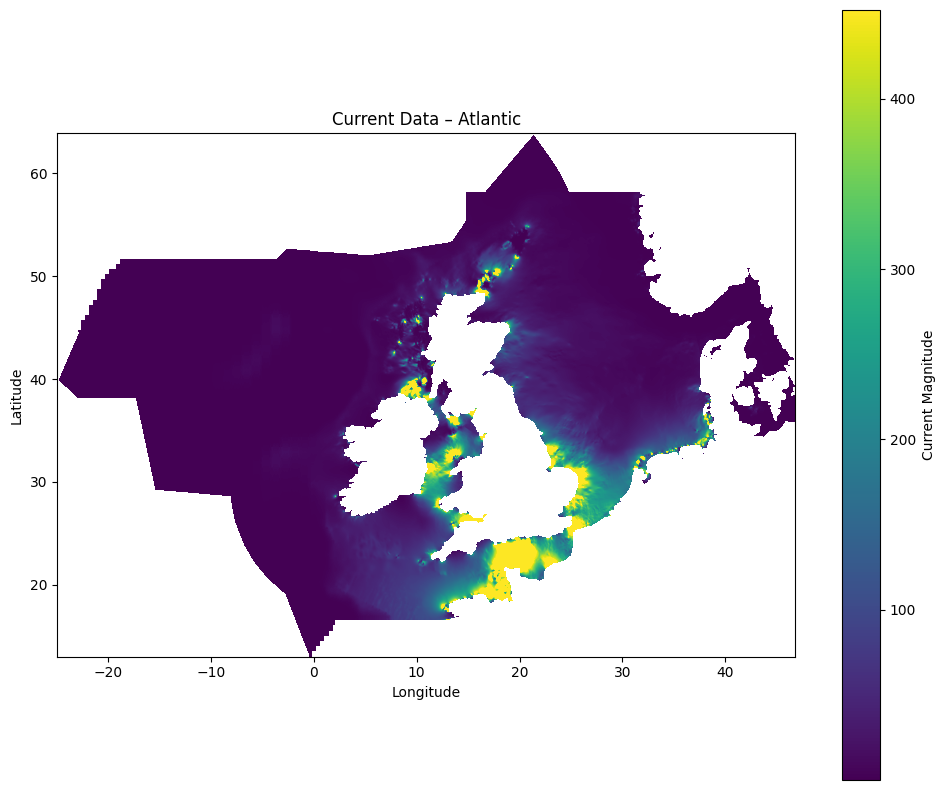

In [23]:
import numpy as np

nodata = current_raster.nodata
data = current_data.astype(float)

if nodata is not None:
    data[data == nodata] = np.nan

# Also mask absurd values
data[np.abs(data) > 1e10] = np.nan
vmin, vmax = np.nanpercentile(data, [2, 98])
plt.figure(figsize=(10, 8))
plt.imshow(
    data,
    cmap="viridis",
    extent=current_bounds,
    vmin=vmin,
    vmax=vmax,
    origin="upper"   # ← north is north
)

plt.colorbar(label="Current Magnitude")
plt.title("Current Data – Atlantic")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()
